## so warming and nino34 variability and mean state changes in obs and lens

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [4]:
from scipy import stats

In [5]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 12
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 1.5
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

### Functions needed for the analysis

In [2]:
from functions.preproc_funcs import calc_anom, detrend_separate_check, detrend1d_check, get_corr, get_regr, detrend_dim

In [6]:
from functions import xr_lowess

In [7]:
from functions.preproc_funcs import calc_trend3d, calc_trend_pval3d

In [56]:
obs_sst = xr.open_dataset('../seasonal_period_analysis/data/obs/ersst_v5.nc').sst.resample(time = 'AS-JUN').mean('time')
obs_sst_anom = calc_anom(obs_sst, obs_sst.sel(time = slice('1960', '1990')))

In [57]:
obs_trend = calc_trend3d(obs_sst_anom.sel(time = slice('1980', '2022')), 'time')

In [58]:
obs_trend1 = calc_trend3d(obs_sst_anom.sel(time = slice('1960', '2000')), 'time')

In [59]:
obs_trend2 = calc_trend3d(obs_sst_anom.sel(time = slice('1900', '1940')), 'time')

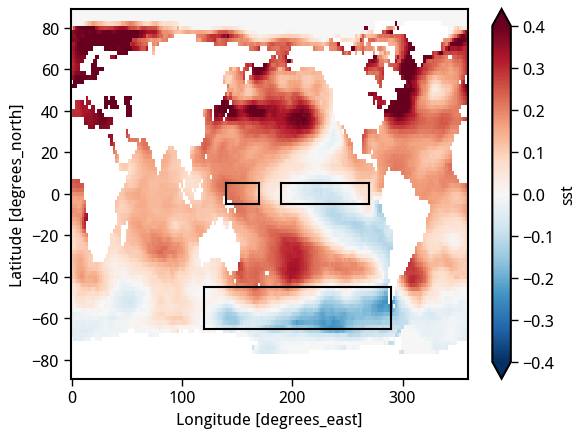

In [60]:
obs_trend.plot(vmin=-0.4, extend='both')
plt.plot([190, 270], [-5, -5], color='k')
plt.plot([190, 270], [5, 5], color='k')
plt.plot([190, 190], [-5, 5], color='k')
plt.plot([270, 270], [-5, 5], color='k')

plt.plot([140, 170], [-5, -5], color='k')
plt.plot([140, 170], [5, 5], color='k')
plt.plot([140, 140], [-5, 5], color='k')
plt.plot([170, 170], [-5, 5], color='k')

plt.plot([120, 290], [-65, -65], color='k')
plt.plot([120, 290], [-45, -45], color='k')
plt.plot([120, 120], [-65, -45], color='k')
plt.plot([290, 290], [-65, -45], color='k')

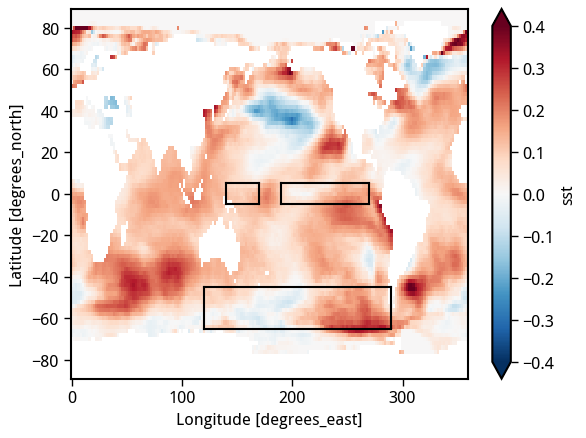

In [61]:
obs_trend1.plot(vmin=-0.4, extend='both')
plt.plot([190, 270], [-5, -5], color='k')
plt.plot([190, 270], [5, 5], color='k')
plt.plot([190, 190], [-5, 5], color='k')
plt.plot([270, 270], [-5, 5], color='k')

plt.plot([140, 170], [-5, -5], color='k')
plt.plot([140, 170], [5, 5], color='k')
plt.plot([140, 140], [-5, 5], color='k')
plt.plot([170, 170], [-5, 5], color='k')

plt.plot([120, 290], [-65, -65], color='k')
plt.plot([120, 290], [-45, -45], color='k')
plt.plot([120, 120], [-65, -45], color='k')
plt.plot([290, 290], [-65, -45], color='k')

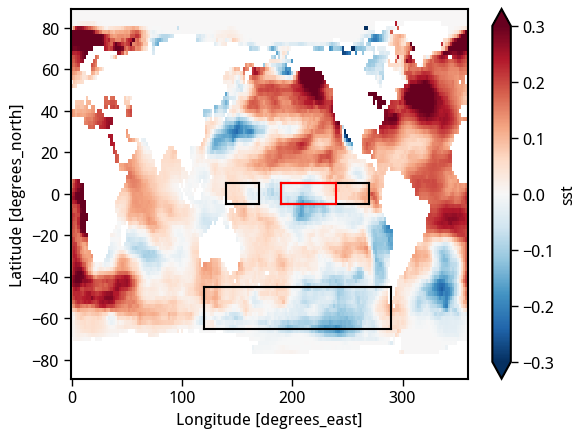

In [68]:
obs_trend2.plot(vmin=-0.3, extend='both')
plt.plot([190, 270], [-5, -5], color='k')
plt.plot([190, 270], [5, 5], color='k')
plt.plot([190, 190], [-5, 5], color='k')
plt.plot([270, 270], [-5, 5], color='k')

plt.plot([190, 240], [-5, -5], color='r')
plt.plot([190, 240], [5, 5], color='r')
plt.plot([190, 190], [-5, 5], color='r')
plt.plot([240, 240], [-5, 5], color='r')

plt.plot([140, 170], [-5, -5], color='k')
plt.plot([140, 170], [5, 5], color='k')
plt.plot([140, 140], [-5, 5], color='k')
plt.plot([170, 170], [-5, 5], color='k')

plt.plot([120, 290], [-65, -65], color='k')
plt.plot([120, 290], [-45, -45], color='k')
plt.plot([120, 120], [-65, -45], color='k')
plt.plot([290, 290], [-65, -45], color='k')

In [80]:
weights = np.cos(np.deg2rad(obs_sst.lat))

In [81]:
obs_nino34_index = detrend1d_check(obs_sst_anom.sel(lat = slice(5,-5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), period=15)
obs_nino3_sst = obs_sst_anom.sel(lat = slice(5,-5), lon = slice(-150+360, -90+360)).weighted(weights).mean(('lat', 'lon'))
obs_nino4_sst = obs_sst_anom.sel(lat = slice(5,-5), lon = slice(160, -150+360)).weighted(weights).mean(('lat', 'lon'))
obs_wp_sst = obs_sst_anom.sel(lat = slice(5,-5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon'))
obs_ct_sst = obs_sst_anom.sel(lat = slice(5,-5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))
obs_so_sst = obs_sst_anom.sel(lat = slice(-45, -65), lon = slice(120, 290)).weighted(weights).mean(('lat', 'lon'))

In [82]:
obs_nino34_index.sel(time = slice('1980', '2020')).std()

<xarray.DataArray 'sst' ()>
array(0.79052186)

In [83]:
import pymannkendall as mk

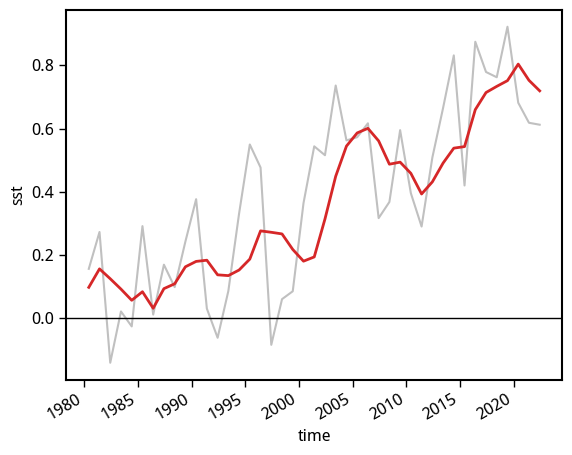

In [89]:
# obs_wp_sst.sel(time = slice('1980', '2024')).plot()
obs_wp_sst.sel(time = slice('1980', '2022')).plot(color='silver')
obs_wp_sst.rolling(time = 5).mean('time').sel(time = slice('1980', '2022')).plot(color='tab:red', lw=2.0)
# obs_nino4_sst.sel(time = slice('1980', '2020')).plot()
# obs_nino3_sst.sel(time = slice('1980', '2020')).plot()
plt.axhline(0.0, color='k', lw=1.0)

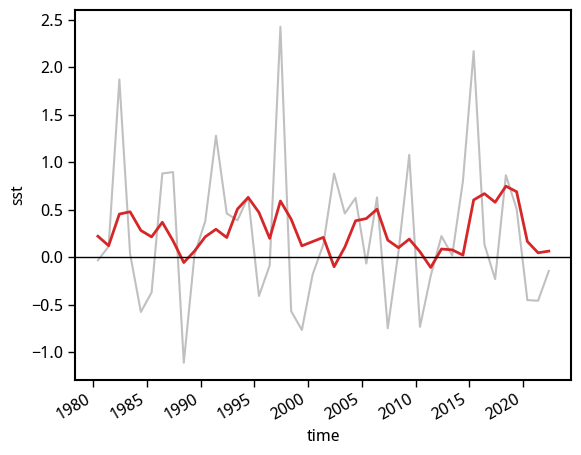

In [88]:
# obs_wp_sst.sel(time = slice('1980', '2024')).plot()
obs_ct_sst.sel(time = slice('1980', '2022')).plot(color='silver')
obs_ct_sst.rolling(time = 5).mean('time').sel(time = slice('1980', '2022')).plot(color='tab:red', lw=2.0)
# obs_nino4_sst.sel(time = slice('1980', '2020')).plot()
# obs_nino3_sst.sel(time = slice('1980', '2020')).plot()
plt.axhline(0.0, color='k', lw=1.0)

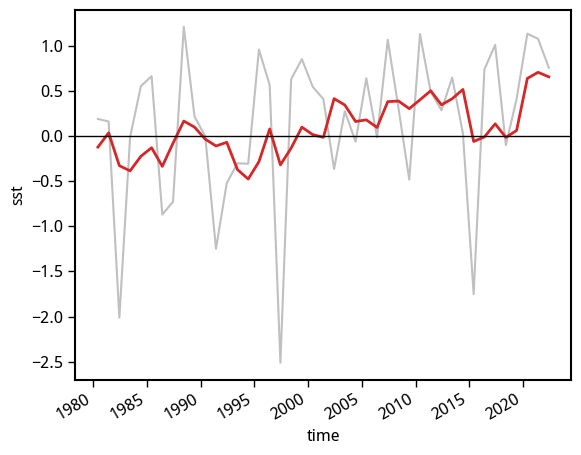

In [90]:
(obs_wp_sst - obs_ct_sst).sel(time = slice('1980', '2022')).plot(color='silver')
(obs_wp_sst - obs_ct_sst).rolling(time = 5).mean('time').sel(time = slice('1980', '2022')).plot(color='tab:red', lw=2.0)
plt.axhline(0.0, color='k', lw=1.0)

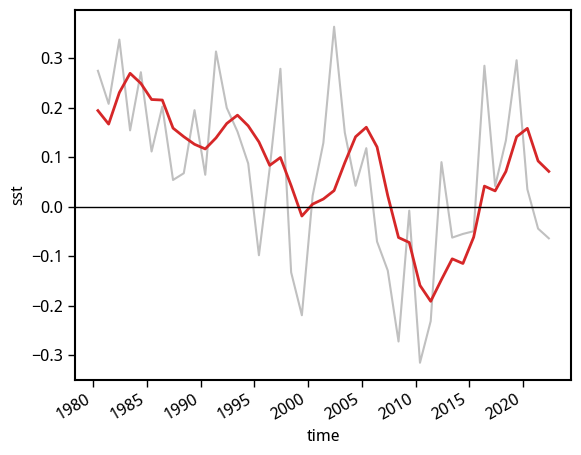

In [91]:
(obs_so_sst).sel(time = slice('1980', '2022')).plot(color='silver')
(obs_so_sst).rolling(time = 5).mean('time').sel(time = slice('1980', '2022')).plot(color='tab:red', lw=2.0)
plt.axhline(0.0, color='k', lw=1.0)

In [92]:
mk.hamed_rao_modification_test((obs_wp_sst).sel(time = slice('1980', '2022')))

Modified_Mann_Kendall_Test_Hamed_Rao_Approach(trend='increasing', h=True, p=4.68287832955383e-08, z=5.462949506654428, Tau=0.5791805094130675, s=523.0, var_s=9130.333333333334, slope=0.017654010023062047, intercept=0.006256465441905501)

In [93]:
mk.hamed_rao_modification_test((obs_ct_sst).sel(time = slice('1980', '2022')))

Modified_Mann_Kendall_Test_Hamed_Rao_Approach(trend='no trend', h=False, p=0.5715359467925825, z=-0.5657908801554228, Tau=-0.036544850498338874, s=-33.0, var_s=3198.8072440786336, slope=-0.0022287715512972614, intercept=0.15910844304240668)

In [94]:
mk.hamed_rao_modification_test((obs_wp_sst - obs_ct_sst).sel(time = slice('1980', '2022')))

Modified_Mann_Kendall_Test_Hamed_Rao_Approach(trend='increasing', h=True, p=1.2876001420636385e-06, z=4.841658340702294, Tau=0.2425249169435216, s=219.0, var_s=2027.331219168428, slope=0.019469235254370647, intercept=-0.12279000100882154)

In [96]:
mk.hamed_rao_modification_test((obs_so_sst).sel(time = slice('1980', '2015')))

Modified_Mann_Kendall_Test_Hamed_Rao_Approach(trend='decreasing', h=True, p=9.260357274043507e-05, z=-3.9091966159069282, Tau=-0.45714285714285713, s=-288.0, var_s=5390.0, slope=-0.009973704149491492, intercept=0.25704135698866926)

In [27]:
tpi_df = pd.read_csv('./data/TPI_data.csv')
tpi_df.replace(-99, np.nan, inplace=True)

In [28]:
tpi_da = xr.DataArray(
    data = tpi_df.set_index('year').to_numpy().flatten(),
    dims = ["time"],
    coords = dict(
        time = (["time"], pd.date_range(start='1870-01', end='2025-01', freq='1M'))
    )
)

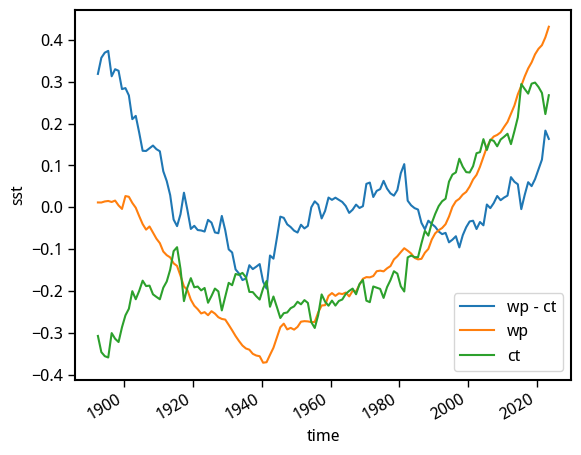

In [97]:
# obs_nino34_index.rolling(time = 40*12).std('time').plot()
(obs_wp_sst - obs_ct_sst).rolling(time = 40).mean('time').plot(label='wp - ct')
obs_wp_sst.rolling(time = 40).mean('time').plot(label = 'wp')
obs_ct_sst.rolling(time = 40).mean('time').plot(label = 'ct')
# obs_so_sst.rolling(time = 40*12).mean('time').plot()
plt.legend()

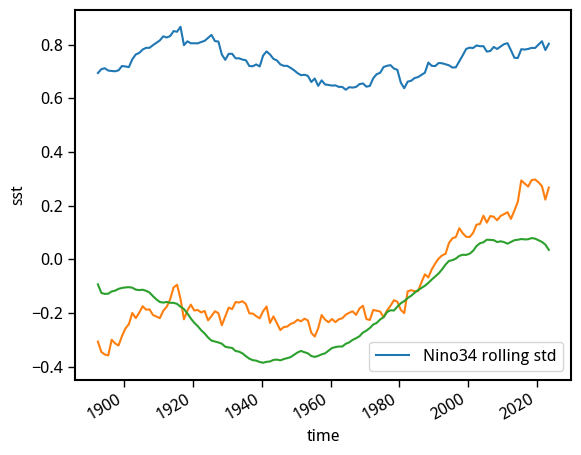

In [98]:
obs_nino34_index.rolling(time = 40).std('time').plot(label='Nino34 rolling std')
obs_ct_sst.rolling(time = 40).mean('time').plot()
obs_so_sst.rolling(time = 40).mean('time').plot()
plt.legend()

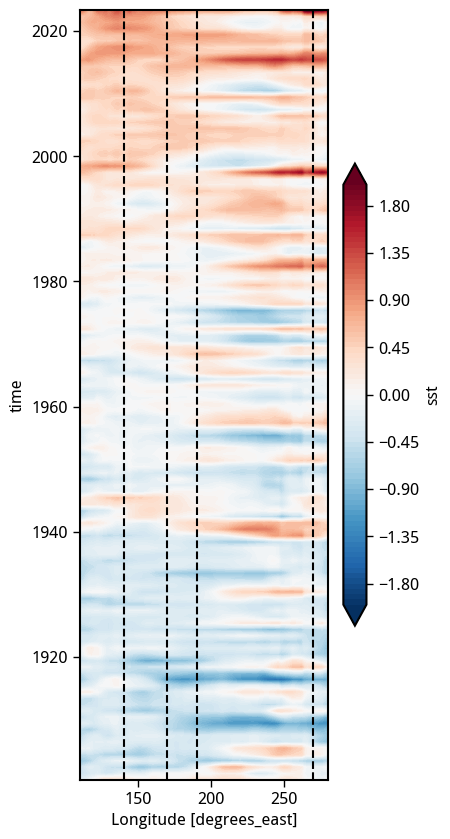

In [99]:
plt.figure(figsize=(4,10))
obs_sst_anom.sel(lat = slice(30, -20), lon = slice(110, -80+360)).mean('lat').sel(time = slice('1900', '2024')).plot.contourf(cmap='RdBu_r', \
                                                                                                                              levels=np.arange(-2.0, 2.05, 0.05), extend='both', \
                                                                                                                                cbar_kwargs=dict(shrink=0.6))
plt.axvline(140, color='k', ls='--')
plt.axvline(170, color='k', ls='--')
# plt.axvline(160, color='k', ls='--')
plt.axvline(190, color='k', ls='--')
plt.axvline(270, color='k', ls='--')

### checking relationship in picontrol

In [209]:
pic_sst = xr.open_mfdataset('/g/data/oi10/replicas/CMIP6/CMIP/CCCma/CanESM5/piControl/r1i1p1f1/Amon/ts/gn/v20190429/*.nc').resample(time = 'AS-JUN').mean('time').ts.load()
pic_sst

<xarray.DataArray 'ts' (time: 1001, lat: 64, lon: 128)>
array([[[228.45798, 228.15366, 227.74536, ..., 229.47742, 229.17007,
         228.81795],
        [228.05078, 227.3125 , 226.71964, ..., 230.80595, 229.79538,
         228.88716],
        [227.14307, 226.41841, 225.80952, ..., 230.67126, 229.25522,
         228.13225],
        ...,
        [252.02075, 252.47363, 252.86331, ..., 250.43387, 251.01477,
         251.5336 ],
        [250.10287, 250.22038, 250.29524, ..., 249.39815, 249.65865,
         249.89389],
        [248.56099, 248.61435, 248.62451, ..., 248.39803, 248.48169,
         248.5249 ]],

       [[228.18077, 227.8289 , 227.48047, ..., 229.21516, 228.85887,
         228.49504],
        [228.20311, 227.47408, 226.81958, ..., 230.87904, 229.9071 ,
         229.00368],
        [227.87256, 227.03058, 226.41206, ..., 231.68604, 230.20317,
         228.93571],
...
        [253.41817, 253.69133, 253.90686, ..., 252.3531 , 252.7199 ,
         253.08089],
        [251.77582, 251.90016, 252.01825, ..., 251.40894, 251.53142,
         251.67334],
        [251.54431, 251.59584, 251.632  , ..., 251.45898, 251.48512,
         251.5155 ]],

       [[224.9511 , 224.6097 , 224.30095, ..., 225.94948, 225.59409,
         225.26527],
        [224.35446, 223.67262, 223.099  , ..., 227.0426 , 226.07564,
         225.14644],
        [222.69705, 221.80887, 221.19069, ..., 226.68494, 225.16261,
         223.81557],
        ...,
        [258.4602 , 258.80356, 259.15646, ..., 257.4452 , 257.74808,
         258.05606],
        [258.12985, 258.31912, 258.44427, ..., 257.5887 , 257.74615,
         257.91803],
        [257.582  , 257.6059 , 257.6261 , ..., 257.51093, 257.56277,
         257.5825 ]]], dtype=float32)
Coordinates:
  * lat      (lat) float64 -87.86 -85.1 -82.31 -79.53 ... 79.53 82.31 85.1 87.86
  * lon      (lon) float64 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
  * time     (time) object 5200-06-01 00:00:00 ... 6200-06-01 00:00:00
Attributes:
    standard_name:  surface_temperature
    long_name:      Surface Temperature
    comment:        GT+273.16, CMIP_table_comment: Temperature of the lower b...
    units:          K
    original_name:  GT
    history:        degctok 2019-04-30T17:18:18Z altered by CMOR: Reordered d...
    cell_methods:   area: time: mean
    cell_measures:  area: areacella

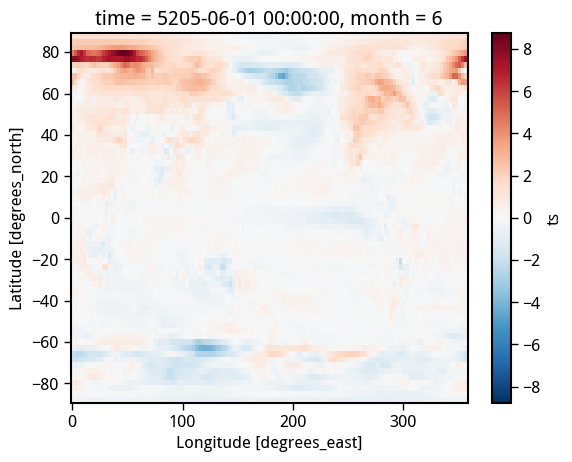

In [210]:
pic_sst_anom = calc_anom(pic_sst, pic_sst.isel(time = slice(0, 50)))
pic_sst_anom.isel(time=5).plot()

In [211]:
weights = np.cos(np.deg2rad(pic_sst.lat))

In [212]:
pic_nino34_index = detrend1d_check(pic_sst_anom.sel(lat = slice(5,-5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), period=15)
pic_wp_sst = pic_sst_anom.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon'))
pic_ct_sst = pic_sst_anom.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))
pic_so_sst = pic_sst_anom.sel(lat = slice(-65, -45), lon = slice(120, 290)).weighted(weights).mean(('lat', 'lon'))
# pic_rand = pic_sst_anom.sel(lat = slice(30, 45), lon = slice(60, 100)).weighted(weights).mean(('lat', 'lon'))

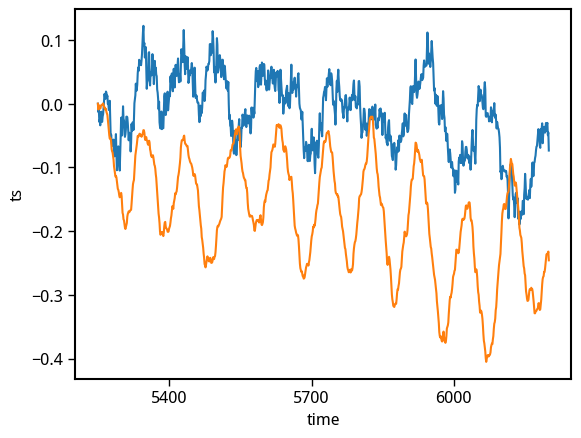

In [219]:
# (pic_wp_sst - pic_ct_sst).rolling(time = 30).mean('time').plot()
# (pic_wp_sst).rolling(time = 10).mean('time').plot()
pic_ct_sst.rolling(time = 50).mean('time').plot()
# pic_rand.rolling(time = 10).mean('time').plot()
pic_so_sst.rolling(time = 50).mean('time').plot()

In [221]:
xx = (pic_ct_sst).rolling(time = 50).mean('time')
yy = pic_so_sst.rolling(time = 50).mean('time')
stats.spearmanr(xx[~(np.isnan(xx) | np.isnan(yy))], yy[~(np.isnan(xx) | np.isnan(yy))])

SignificanceResult(statistic=0.33279332898266345, pvalue=4.712114834989881e-26)

In [33]:
# access_df = sst_sector_trends_lens(40, model_name='access')

In [34]:
# access_df.head()

In [35]:
# access_df.to_csv('./data/res_var_mean_state/access.csv')

In [36]:
from scipy import stats

In [37]:
access_df = pd.read_csv('./data/res_var_mean_state/access.csv')
miroc6_df = pd.read_csv('./data/res_var_mean_state/miroc6.csv')
miroc_esm2l_df = pd.read_csv('./data/res_var_mean_state/miroc_esm2l.csv')
mpi_df = pd.read_csv('./data/res_var_mean_state/mpi.csv')
mpi_cmip6_df = pd.read_csv('./data/res_var_mean_state/mpi_cmip6.csv')
ipsl_cm6a_df = pd.read_csv('./data/res_var_mean_state/ipsl_cm6a.csv')
gfdl_spear_df = pd.read_csv('./data/res_var_mean_state/gfdl_spear.csv')
csiro_mk36_df = pd.read_csv('./data/res_var_mean_state/csiro_mk36.csv')
cesm1_df = pd.read_csv('./data/res_var_mean_state/cesm1.csv')
canesm2_df = pd.read_csv('./data/res_var_mean_state/canesm2.csv')
canesm5_df = pd.read_csv('./data/res_var_mean_state/canesm5.csv')

In [38]:

combined_lens = pd.concat([access_df, miroc6_df, miroc_esm2l_df, mpi_df, mpi_cmip6_df, ipsl_cm6a_df, gfdl_spear_df, csiro_mk36_df, cesm1_df, canesm2_df, canesm5_df])

In [39]:
import seaborn as sns

In [40]:
miroc6_df

,Unnamed: 0,n34_var,mean_state_trend,mean_state_pval
0,0,1.411679,-0.016251,0.003464
1,1,1.548400,-0.008179,0.069446
2,2,1.387871,-0.005529,0.510207
3,3,1.498548,0.000324,0.934833
4,4,1.189608,-0.004599,0.099629
5,5,1.374984,-0.010336,0.005106
6,6,1.215729,0.002140,0.698689
7,7,1.451066,0.001166,0.843832
8,8,1.345335,-0.019896,0.000755
9,9,1.411341,-0.007443,0.071993


In [41]:
from mycolorpy import colorlist as mcp


In [42]:
color1=mcp.gen_color(cmap="tab10",n=11)
color1

['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22',
 '#17becf',
 '#17becf']

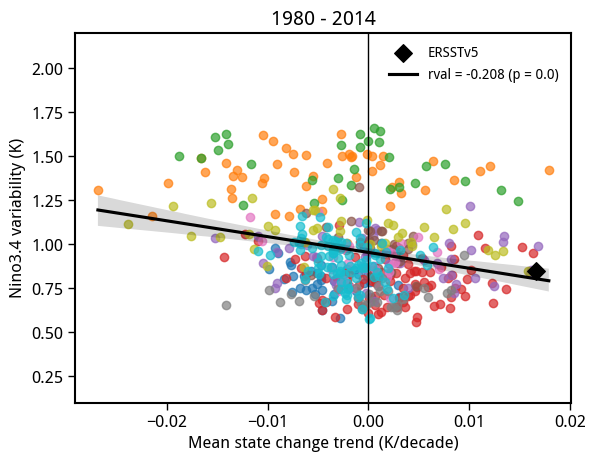

In [43]:
# plt.axhline(0.0, color='k', lw=1.0)
plt.axvline(0.0, color='k', lw=1.0)
plt.scatter(access_df['mean_state_trend'], access_df['n34_var'], color=color1[0], alpha=0.7)
plt.scatter(miroc6_df['mean_state_trend'], miroc6_df['n34_var'], color=color1[1], alpha=0.7)
plt.scatter(miroc_esm2l_df['mean_state_trend'], miroc_esm2l_df['n34_var'], color=color1[2], alpha=0.7)
plt.scatter(mpi_df['mean_state_trend'], mpi_df['n34_var'], color=color1[3], alpha=0.7)
plt.scatter(mpi_cmip6_df['mean_state_trend'], mpi_cmip6_df['n34_var'], color=color1[4], alpha=0.7)
plt.scatter(ipsl_cm6a_df['mean_state_trend'], ipsl_cm6a_df['n34_var'], color=color1[5], alpha=0.7)
plt.scatter(gfdl_spear_df['mean_state_trend'], gfdl_spear_df['n34_var'], color=color1[6], alpha=0.7)
plt.scatter(csiro_mk36_df['mean_state_trend'], csiro_mk36_df['n34_var'], color=color1[7], alpha=0.7)
plt.scatter(cesm1_df['mean_state_trend'], cesm1_df['n34_var'], color=color1[8], alpha=0.7)
plt.scatter(canesm2_df['mean_state_trend'], canesm2_df['n34_var'], color=color1[9], alpha=0.7)
plt.scatter(canesm5_df['mean_state_trend'], canesm5_df['n34_var'], color=color1[10], alpha=0.7)
plt.scatter(obs_mean_state_trend, obs_n34_var, color='k', marker='D', s=80, label='ERSSTv5')

res = stats.spearmanr(combined_lens['mean_state_trend'], combined_lens['n34_var'])
sns.regplot(x = combined_lens['mean_state_trend'], y=combined_lens['n34_var'], scatter=False, color='k', label = f'rval = {np.round(res.statistic, 3)} (p = {np.round(res.pvalue, 3)})')
# sns.regplot(x = access_df['mean_state_trend'], y=access_df['n34_var'], scatter=False, color=color1[0])
# sns.regplot(x = miroc6_df['mean_state_trend'], y=miroc6_df['n34_var'], scatter=False, color=color1[1])
# sns.regplot(x = mpi_df['mean_state_trend'], y=mpi_df['n34_var'], scatter=False, color=color1[3])
# sns.regplot(x = canesm5_df['mean_state_trend'], y=canesm5_df['n34_var'], scatter=False, color=color1[10])
plt.xlabel('Mean state change trend (K/decade)')
plt.ylabel('Nino3.4 variability (K)')
plt.title('1980 - 2014')
plt.ylim(0.1, 2.2)
plt.legend(frameon=False, fontsize=10)

In [186]:
hist_tos = xc.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/hist_ssp_runs/regrid_sst/hist_r10i1p1f1.nc').tos
ssp_tos = xc.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/hist_ssp_runs/regrid_sst/ssp_r10i1p1f1.nc').tos
trans_tos = xr.concat([hist_tos, ssp_tos], dim='time')

In [187]:
trans_tos['time'] = xr.cftime_range('1850-01-01', '2100-12-31', freq='1M')

In [245]:
stable_tos = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/stable_runs/sst_field_regrid/sst_PI-GWL-B2060.nc').sst.load()

In [246]:
stable_tos['time'] = xr.cftime_range('2060-01-01', '3060-01-01', freq='1M')

In [247]:
trans_tos_anom = calc_anom(trans_tos, trans_tos.sel(time = slice('1960', '1990')))
stable_tos_anom = calc_anom(stable_tos, trans_tos.sel(time = slice('1960', '1990')))

In [248]:
model_weights = np.cos(np.deg2rad(trans_tos_anom.lat))
model_weights

<xarray.DataArray 'lat' (lat: 120)>
array([0.0130896 , 0.03925982, 0.06540313, 0.09150162, 0.1175374 ,
       0.14349262, 0.1693495 , 0.19509032, 0.22069744, 0.24615329,
       0.27144045, 0.29654157, 0.32143947, 0.34611706, 0.37055744,
       0.39474386, 0.41865974, 0.44228869, 0.46561452, 0.48862124,
       0.51129309, 0.53361452, 0.55557023, 0.57714519, 0.5983246 ,
       0.61909395, 0.639439  , 0.65934582, 0.67880075, 0.69779046,
       0.71630194, 0.73432251, 0.75183981, 0.76884183, 0.78531693,
       0.80125381, 0.81664156, 0.83146961, 0.84572782, 0.85940641,
       0.87249601, 0.88498764, 0.89687274, 0.90814317, 0.91879121,
       0.92880955, 0.93819134, 0.94693013, 0.95501994, 0.96245524,
       0.96923091, 0.97534232, 0.98078528, 0.98555606, 0.98965139,
       0.99306846, 0.99580493, 0.99785892, 0.99922904, 0.99991433,
       0.99991433, 0.99922904, 0.99785892, 0.99580493, 0.99306846,
       0.98965139, 0.98555606, 0.98078528, 0.97534232, 0.96923091,
       0.96245524, 0.95501994, 0.94693013, 0.93819134, 0.92880955,
       0.91879121, 0.90814317, 0.89687274, 0.88498764, 0.87249601,
       0.85940641, 0.84572782, 0.83146961, 0.81664156, 0.80125381,
       0.78531693, 0.76884183, 0.75183981, 0.73432251, 0.71630194,
       0.69779046, 0.67880075, 0.65934582, 0.639439  , 0.61909395,
       0.5983246 , 0.57714519, 0.55557023, 0.53361452, 0.51129309,
       0.48862124, 0.46561452, 0.44228869, 0.41865974, 0.39474386,
       0.37055744, 0.34611706, 0.32143947, 0.29654157, 0.27144045,
       0.24615329, 0.22069744, 0.19509032, 0.1693495 , 0.14349262,
       0.1175374 , 0.09150162, 0.06540313, 0.03925982, 0.0130896 ])
Coordinates:
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y
    bounds:         lat_bnds

In [249]:
nino34_trans = detrend1d_check(trans_tos_anom.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).weighted(model_weights).mean(('lat', 'lon')), period=15*12).rolling(time = 5, center=True).mean('time')

In [250]:
nino34_stable = detrend1d_check(stable_tos_anom.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).weighted(model_weights).mean(('lat', 'lon')), period=15*12).rolling(time = 5, center=True).mean('time')

In [251]:
wp_sst = trans_tos_anom.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(model_weights).mean(('lat', 'lon'))
ct_sst = trans_tos_anom.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(model_weights).mean(('lat', 'lon'))
so_sst = trans_tos_anom.sel(lat = slice(-70, -45), lon = slice(120, 290)).weighted(model_weights).mean(('lat', 'lon'))

In [252]:
wp_sst_stable = stable_tos_anom.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(model_weights).mean(('lat', 'lon'))
ct_sst_stable = stable_tos_anom.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(model_weights).mean(('lat', 'lon'))
so_sst_stable = stable_tos_anom.sel(lat = slice(-70, -45), lon = slice(120, 290)).weighted(model_weights).mean(('lat', 'lon'))

In [253]:
import cftime as cft

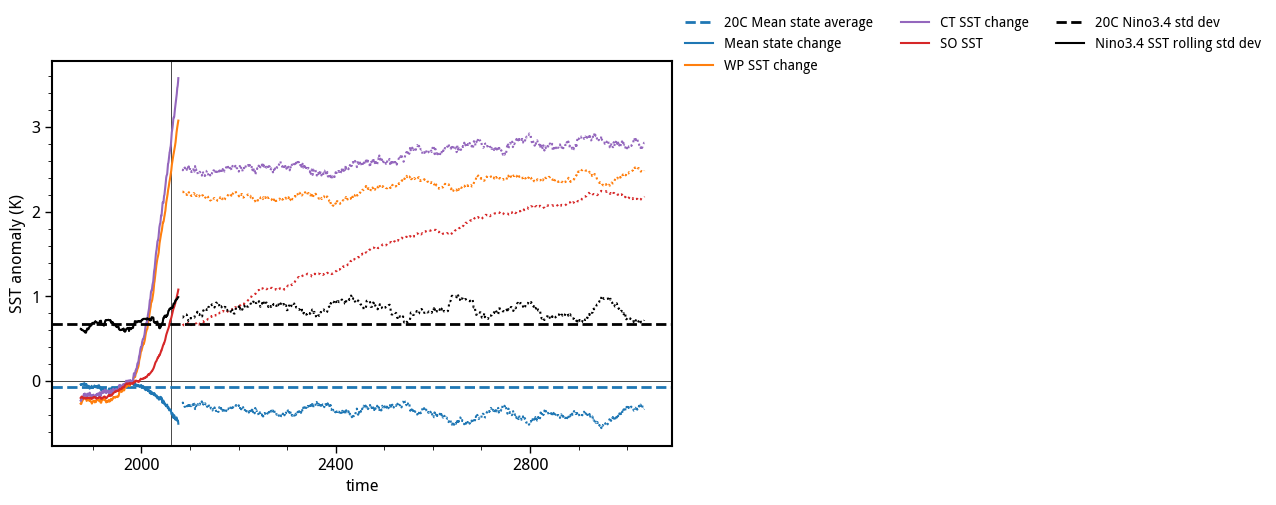

In [255]:
plt.figure(figsize=(8,5))
# plt.axvline(cft.datetime(2014, 6, 1), color='k', lw=0.5)
plt.axvline(cft.datetime(2060, 6, 1), color='k', lw=0.5)
plt.axhline(0.0, color='k', lw=0.5)

plt.axhline((wp_sst - ct_sst).sel(time = slice('1900', '2000')).mean('time'), color='tab:blue', ls='--', lw=2.0, label='20C Mean state average')
(wp_sst - ct_sst).rolling(time = 50*12, center=True).mean('time').plot(color='tab:blue', label='Mean state change')
(wp_sst_stable - ct_sst_stable).rolling(time = 50*12, center=True).mean('time').plot(color='tab:blue', ls=':')

(wp_sst).rolling(time = 50*12, center=True).mean('time').plot(color='tab:orange', label='WP SST change')
(wp_sst_stable).rolling(time = 50*12, center=True).mean('time').plot(color='tab:orange', ls=':')
(ct_sst).rolling(time = 50*12, center=True).mean('time').plot(color='tab:purple', label='CT SST change')
(ct_sst_stable).rolling(time = 50*12, center=True).mean('time').plot(color='tab:purple', ls=':')

(so_sst).rolling(time = 50*12, center=True).mean('time').plot(color='tab:red', label='SO SST')
(so_sst_stable).rolling(time = 50*12, center=True).mean('time').plot(color='tab:red', ls=':')

plt.axhline(nino34_trans.sel(time = slice('1900', '2000')).std('time'), color='k', ls='--', lw=2.0, label='20C Nino3.4 std dev')
# plt.axhline(nino34_trans.sel(time = slice('2000', '2100')).std('time'), color='k', lw=2.0)
nino34_trans.rolling(time = 50*12, center=True).std('time').plot(color='k', label='Nino3.4 SST rolling std dev')

nino34_stable.rolling(time = 50*12, center=True).std('time').plot(color='k', ls=':')

plt.legend(frameon=False, fontsize=10, ncol=3, bbox_to_anchor=[1.0, 1.15])
plt.ylabel('SST anomaly (K)')
plt.minorticks_on()

In [80]:
stats.skew(nino34_trans.sel(time = slice('1900', '2000')))

-0.18530633685098766

In [81]:
stats.skew(obs_nino34_index.sel(time = slice('1900', '2000')))

0.24152437480230882

In [73]:
xx = (wp_sst_stable - ct_sst_stable).rolling(time = 50*12, center=True).mean('time').to_numpy()
yy = nino34_stable.rolling(time = 50*12, center=True).std('time').to_numpy()
stats.spearmanr(xx[~(np.isnan(xx) | np.isnan(yy))], yy[~(np.isnan(xx) | np.isnan(yy))])

SignificanceResult(statistic=-0.36815685120562686, pvalue=0.0)

In [74]:
xx = (wp_sst - ct_sst).rolling(time = 50*12, center=True).mean('time').to_numpy()
yy = nino34_trans.rolling(time = 50*12, center=True).std('time').to_numpy()
stats.spearmanr(xx[~(np.isnan(xx) | np.isnan(yy))], yy[~(np.isnan(xx) | np.isnan(yy))])

SignificanceResult(statistic=-0.7154840231803982, pvalue=0.0)

In [75]:
xx = (wp_sst - ct_sst).sel(time = slice('1850', '2000')).rolling(time = 50*12, center=True).mean('time')
yy = nino34_trans.sel(time = slice('1850', '2000')).rolling(time = 50*12, center=True).std('time')
zz = so_sst.sel(time = slice('1850', '2000')).rolling(time = 50*12, center=True).mean('time')

SignificanceResult(statistic=-0.7804090417100145, pvalue=8.512895760425137e-298)

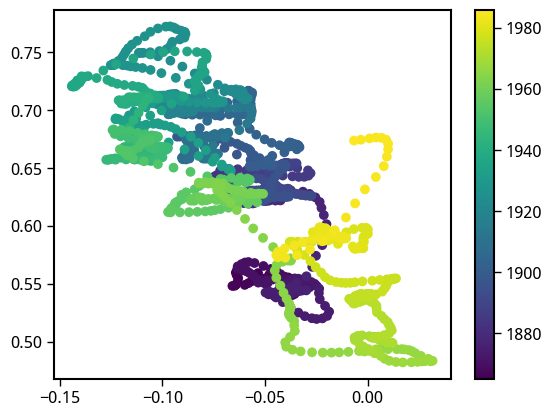

In [70]:
cf=plt.scatter(xx[~(np.isnan(xx) | np.isnan(yy))], yy[~(np.isnan(xx) | np.isnan(yy))], c=xx[~(np.isnan(xx) | np.isnan(yy))].time.dt.year)
plt.colorbar(cf)
stats.spearmanr(xx[~(np.isnan(xx) | np.isnan(yy))], yy[~(np.isnan(xx) | np.isnan(yy))])

SignificanceResult(statistic=0.08032959175861794, pvalue=0.005120220527478905)

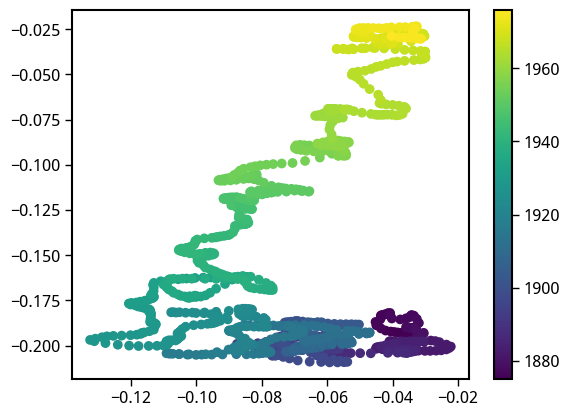

In [76]:
cf=plt.scatter(xx[~(np.isnan(xx) | np.isnan(zz))], zz[~(np.isnan(xx) | np.isnan(zz))], c=xx[~(np.isnan(xx) | np.isnan(zz))].time.dt.year)
plt.colorbar(cf)
stats.spearmanr(xx[~(np.isnan(xx) | np.isnan(zz))], zz[~(np.isnan(xx) | np.isnan(zz))])

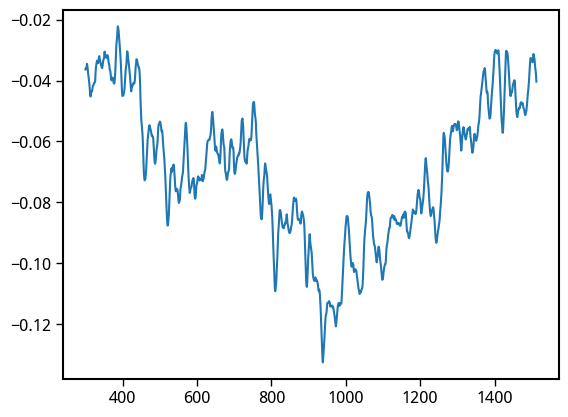

In [77]:
plt.plot(xx)
# plt.plot(yy)

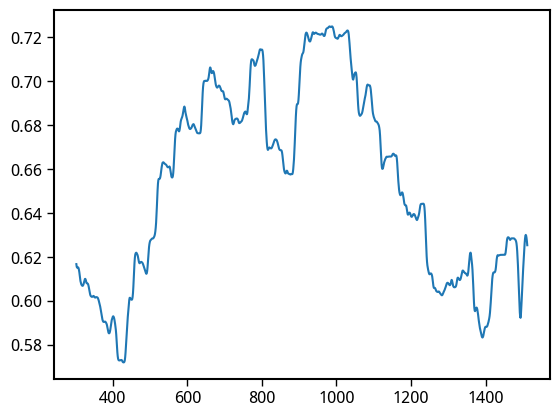

In [78]:
plt.plot(yy)

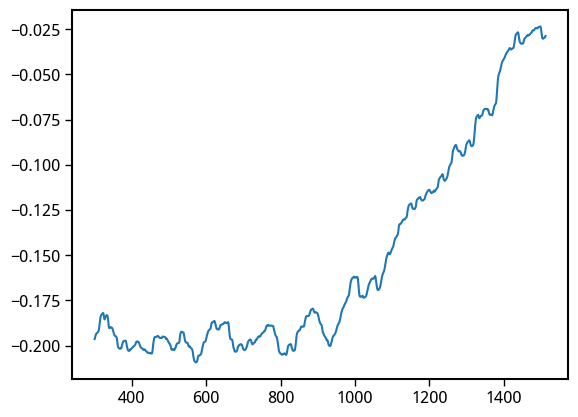

In [79]:
plt.plot(zz)

In [29]:
test = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/stable_runs/ty_trans_field/ty_trans_PI-GWL-B2030_mon.nc')['ty_trans'].load()

In [ ]:
test.isel(time = 0).plot()

In [ ]:
test.sel(lat = 40, method='nearest').sel(lon = slice(-90, ))